Veneziano - Milestone 2

Step # 1: Load Dataset and inspect the first few rows

In [4]:
import pandas as pd

# Load the dataset
life_expectancy = "Life Expectancy Data.csv"
df = pd.read_csv(life_expectancy)

# Inspect the first few rows
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


I started by loading the dataset from a CSV file into a pandas DataFrame and took a look at the first few rows. This gave me an initial understanding of the data structure and the type of information in each column.

Step # 2: Identify countries with missing values

In [8]:
# Checking the original shape of the dataset before cleaning
df.shape

(2938, 22)

In [10]:
# Checking for missing values by country
missing_by_country = df.groupby('Country').apply(lambda x: x.isnull().sum())

# Display countries with missing values
countries_with_missing = missing_by_country[missing_by_country.sum(axis=1) > 0]
print(countries_with_missing)

                                    Country  Year  Status  Life expectancy   \
Country                                                                       
Algeria                                   0     0       0                 0   
Angola                                    0     0       0                 0   
Antigua and Barbuda                       0     0       0                 0   
Argentina                                 0     0       0                 0   
Armenia                                   0     0       0                 0   
...                                     ...   ...     ...               ...   
Venezuela (Bolivarian Republic of)        0     0       0                 0   
Viet Nam                                  0     0       0                 0   
Yemen                                     0     0       0                 0   
Zambia                                    0     0       0                 0   
Zimbabwe                                  0     0   

There are a significant number of countries with missing data, but instead of removing them, I’ve decided to retain these countries and handle the missing values through imputation or other strategies.

In [13]:
# Get the total number of missing values for each column
df.isnull().sum()

Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
 BMI                                34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
 HIV/AIDS                            0
GDP                                448
Population                         652
 thinness  1-19 years               34
 thinness 5-9 years                 34
Income composition of resources    167
Schooling                          163
dtype: int64

I checked for missing values across countries to see which countries had incomplete data. This helped me understand where the missing data was concentrated and how much of it there was. 

Step # 3: Drop columns with over 200 missing values

In [17]:
# Identify the columns with more than 200 missing values
columns_to_drop = df.columns[df.isnull().sum() > 200]

# Drop the columns from the datafame
df_cleaned = df.drop(columns=columns_to_drop)

# Check the remaining columns
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 18 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Measles                          2938 non-null   int64  
 9    BMI                             2904 non-null   float64
 10  under-five deaths                2938 non-null   int64  
 11  Polio                            2919 non-null   float64
 12  Diphtheria          

I identified columns that had over 200 missing values and decided to drop those columns from the dataset. This step was necessary to avoid working with columns that had too many gaps, which would weaken the analysis.

Step # 4: Check for duplicates

In [21]:
duplicates = df_cleaned.duplicated().sum()

# Drop duplicates if they exist
df_cleaned = df_cleaned.drop_duplicates()

print(f"Removed {duplicates} duplicate row.")

Removed 0 duplicate row.


I checked for any duplicate rows in the dataset and removed them. This ensured that each row was unique, which is essential for accurate analysis.

Step # 5: Fix Column names

In [25]:
# Strip whitespaces from column names
df_cleaned.columns = df_cleaned.columns.str.strip()

# Check the cleaned column names
print(df_cleaned.columns)

Index(['Country', 'Year', 'Status', 'Life expectancy', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Measles', 'BMI',
       'under-five deaths', 'Polio', 'Diphtheria', 'HIV/AIDS',
       'thinness  1-19 years', 'thinness 5-9 years',
       'Income composition of resources', 'Schooling'],
      dtype='object')


I cleaned up the column names by stripping out any unnecessary spaces. This step made it easier to reference the columns consistently in the rest of my work.

Step # 6: Decide whether to use mean or median to fill missing values using a automated decision

I used a function to help decide whether to fill missing values in each column with the mean or the median. The decision was based on how skewed the data was, to make sure the imputed values best represented the distribution.

Step # 7: Impute missing values with mean or median

In [33]:
# Impute missing values with median for specific columns
df_cleaned['Life expectancy'] = df_cleaned['Life expectancy'].fillna(df_cleaned['Life expectancy'].median())
df_cleaned['Adult Mortality'] = df_cleaned['Adult Mortality'].fillna(df_cleaned['Adult Mortality'].median())
df_cleaned['infant deaths'] = df_cleaned['infant deaths'].fillna(df_cleaned['infant deaths'].median())
df_cleaned['under-five deaths'] = df_cleaned['under-five deaths'].fillna(df_cleaned['under-five deaths'].median())
df_cleaned['Polio'] = df_cleaned['Polio'].fillna(df_cleaned['Polio'].median())
df_cleaned['Diphtheria'] = df_cleaned['Diphtheria'].fillna(df_cleaned['Diphtheria'].median())
df_cleaned['Measles'] = df_cleaned['Measles'].fillna(df_cleaned['Measles'].median())
df_cleaned['Alcohol'] = df_cleaned['Alcohol'].fillna(df_cleaned['Alcohol'].median())
df_cleaned['thinness  1-19 years'] = df_cleaned['thinness  1-19 years'].fillna(df_cleaned['thinness  1-19 years'].median())
df_cleaned['thinness 5-9 years'] = df_cleaned['thinness 5-9 years'].fillna(df_cleaned['thinness 5-9 years'].median())
df_cleaned['Income composition of resources'] = df_cleaned['Income composition of resources'].fillna(df_cleaned['Income composition of resources'].median())
df_cleaned['Schooling'] = df_cleaned['Schooling'].fillna(df_cleaned['Schooling'].median())

# Impute missing values with mean for BMI
df_cleaned['BMI'] = df_cleaned['BMI'].fillna(df_cleaned['BMI'].mean())

# Verify if all missing values have been handled
print(df_cleaned.isnull().sum())


Country                            0
Year                               0
Status                             0
Life expectancy                    0
Adult Mortality                    0
infant deaths                      0
Alcohol                            0
percentage expenditure             0
Measles                            0
BMI                                0
under-five deaths                  0
Polio                              0
Diphtheria                         0
HIV/AIDS                           0
thinness  1-19 years               0
thinness 5-9 years                 0
Income composition of resources    0
Schooling                          0
dtype: int64


After deciding on the appropriate method, I filled in the missing values in the dataset using either the mean or the median, depending on the distribution of each column. This ensured that there were no gaps left in the dataset.

Step # 8: Detect outliers 

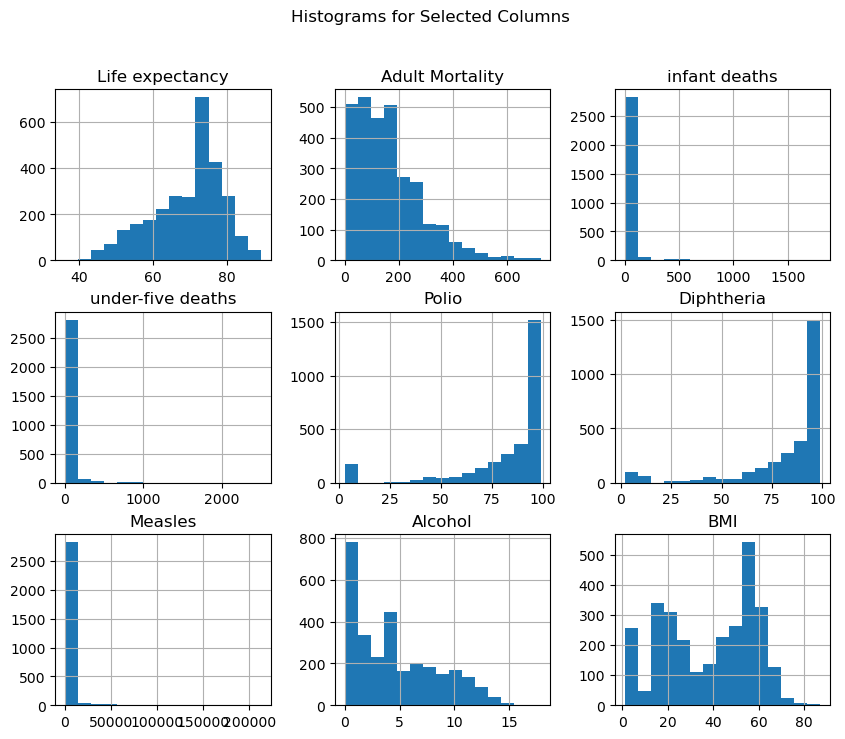

In [37]:
# Plot histograms to detect ouliers
import matplotlib.pyplot as plt
import seaborn as sns

# Define columns to check for outliers
columns_to_check = [
    'Life expectancy', 'Adult Mortality', 'infant deaths', 'under-five deaths',
    'Polio', 'Diphtheria', 'Measles', 'Alcohol', 'BMI'
]

# You can also plot histograms
df_cleaned[columns_to_check].hist(bins=15, figsize=(10, 8))
plt.suptitle('Histograms for Selected Columns')
plt.show()


In [39]:
# Get summary statistics for each column in the DataFrame
summary_statistics = df_cleaned.describe()

# Print the summary statistics
print(summary_statistics)


              Year  Life expectancy  Adult Mortality  infant deaths  \
count  2938.000000      2938.000000      2938.000000    2938.000000   
mean   2007.518720        69.234717       164.725664      30.303948   
std       4.613841         9.509115       124.086215     117.926501   
min    2000.000000        36.300000         1.000000       0.000000   
25%    2004.000000        63.200000        74.000000       0.000000   
50%    2008.000000        72.100000       144.000000       3.000000   
75%    2012.000000        75.600000       227.000000      22.000000   
max    2015.000000        89.000000       723.000000    1800.000000   

           Alcohol  percentage expenditure        Measles          BMI  \
count  2938.000000             2938.000000    2938.000000  2938.000000   
mean      4.546875              738.251295    2419.592240    38.321247   
std       3.921946             1987.914858   11467.272489    19.927677   
min       0.010000                0.000000       0.000000     1.

I plotted histograms and checked summary statistics to detect any outliers in the data. This helped me identify any extreme values that could potentially skew the analysis.

Step # 9: Capping extreme values for outliers

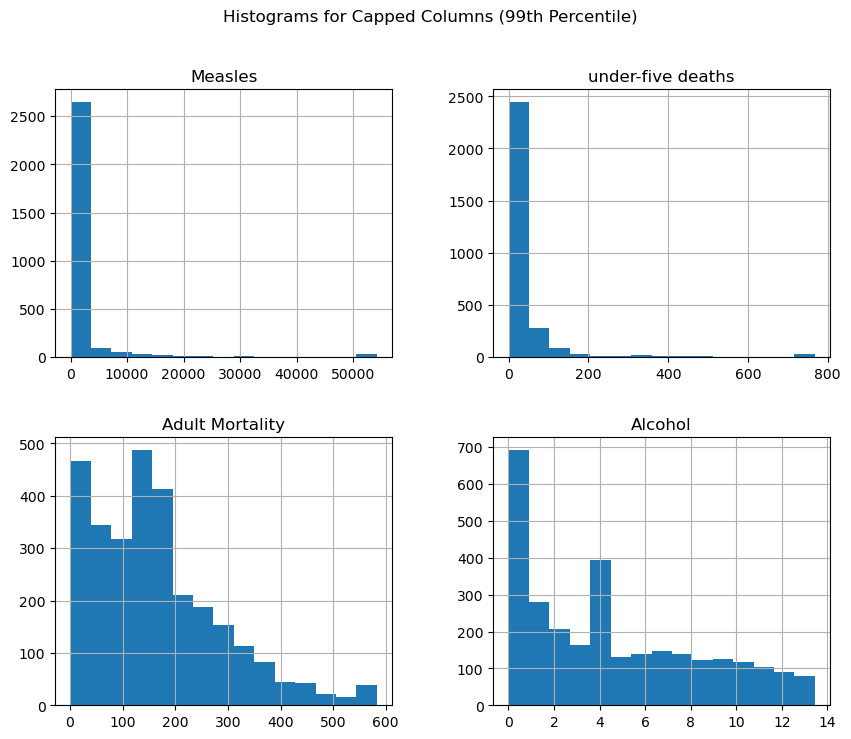

In [43]:
# Capping the extreme values at the 99th percentile
df_cleaned['Measles'] = df_cleaned['Measles'].clip(upper=df_cleaned['Measles'].quantile(0.99))
df_cleaned['under-five deaths'] = df_cleaned['under-five deaths'].clip(upper=df_cleaned['under-five deaths'].quantile(0.99))
df_cleaned['Adult Mortality'] = df_cleaned['Adult Mortality'].clip(upper=df_cleaned['Adult Mortality'].quantile(0.99))
df_cleaned['Alcohol'] = df_cleaned['Alcohol'].clip(upper=df_cleaned['Alcohol'].quantile(0.99))

# Plot histograms for capped columns
columns_to_check = ['Measles', 'under-five deaths', 'Adult Mortality', 'Alcohol']
df_cleaned[columns_to_check].hist(bins=15, figsize=(10, 8))
plt.suptitle('Histograms for Capped Columns (99th Percentile)')
plt.show()


Finally, I capped the extreme values in certain columns, like Measles and under-five deaths, at the 99th percentile. This reduced the impact of outliers without completely removing the data, keeping the analysis robust but reliable.

In the process of wrangling the life expectancy dataset, several changes were made, including handling missing values through imputation, capping outliers, and adjusting column names. These transformations help improve data quality, but they come with ethical considerations. The data, sourced from the World Health Organization (WHO) and the United Nations, must adhere to regulatory guidelines like General Data Protection Regulation (GDPR) if any personal or sensitive data were involved; however, this dataset primarily focuses on country-level statistics and does not involve identifiable personal data. A potential risk arises from the transformations, particularly in capping outliers and imputing missing values, as these changes can obscure real patterns or introduce bias. Assumptions were made when filling in missing values (using mean or median) and when capping extreme values, which could skew the analysis. The data itself was sourced from credible, public institutions like WHO, which ensures its reliability, and no personal data was collected or processed. To address any ethical concerns, it's important to be transparent by clearly explaining all the changes made to the data, the assumptions used, and why certain decisions were made. This way, anyone who uses the data in the future will know exactly how it was modified and can take that into account when analyzing the results.

Step # 10: Print dataset of transformations

In [48]:
# Display the first few rows with formatted precision and background gradient
df_cleaned.style.format(precision=2).background_gradient(cmap='Blues')

The styles table will not print to a pdf, but I want to keep it for my project.

In [50]:
# Print the DataFrame without styling
print(df_cleaned.head(10))


       Country  Year      Status  Life expectancy  Adult Mortality  \
0  Afghanistan  2015  Developing             65.0            263.0   
1  Afghanistan  2014  Developing             59.9            271.0   
2  Afghanistan  2013  Developing             59.9            268.0   
3  Afghanistan  2012  Developing             59.5            272.0   
4  Afghanistan  2011  Developing             59.2            275.0   
5  Afghanistan  2010  Developing             58.8            279.0   
6  Afghanistan  2009  Developing             58.6            281.0   
7  Afghanistan  2008  Developing             58.1            287.0   
8  Afghanistan  2007  Developing             57.5            295.0   
9  Afghanistan  2006  Developing             57.3            295.0   

   infant deaths  Alcohol  percentage expenditure  Measles   BMI  \
0             62     0.01               71.279624   1154.0  19.1   
1             64     0.01               73.523582    492.0  18.6   
2             66     0.01

In [57]:
print(df.head())  # Display the first few rows to confirm it has data
print(f"DataFrame shape: {df.shape}")  # Check that rows and columns are present


       Country  Year      Status  Life expectancy   Adult Mortality  \
0  Afghanistan  2015  Developing              65.0            263.0   
1  Afghanistan  2014  Developing              59.9            271.0   
2  Afghanistan  2013  Developing              59.9            268.0   
3  Afghanistan  2012  Developing              59.5            272.0   
4  Afghanistan  2011  Developing              59.2            275.0   

   infant deaths  Alcohol  percentage expenditure  Hepatitis B  Measles   ...  \
0             62     0.01               71.279624         65.0      1154  ...   
1             64     0.01               73.523582         62.0       492  ...   
2             66     0.01               73.219243         64.0       430  ...   
3             69     0.01               78.184215         67.0      2787  ...   
4             71     0.01                7.097109         68.0      3013  ...   

   Polio  Total expenditure  Diphtheria    HIV/AIDS         GDP  Population  \
0    6.